In [24]:
import yfinance as yf
msft = yf.Ticker("MPC")
aapl = yf.Ticker("PSX")
df_msft=msft.history(period="40y")
df_apple=aapl.history(period="40y")

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import LinearRegression
np.random.seed(9823)

df_msft.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3737.000000,3737.000000,3737.000000,3737.000000,3.737000e+03,3737.000000,3737.000000
mean,66.073657,67.040071,65.138846,66.095356,5.558747e+06,0.007711,0.000535
std,53.642936,54.387837,52.953262,53.688520,3.082732e+06,0.068611,0.032717
min,8.845673,9.175733,8.697142,8.931483,8.952000e+05,0.000000,0.000000
25%,30.051285,30.623962,29.555537,30.092846,3.427400e+06,0.000000,0.000000
50%,42.742528,43.323120,42.246236,42.872799,5.081400e+06,0.000000,0.000000
75%,91.016671,92.141204,88.812120,91.072266,6.929700e+06,0.000000,0.000000
max,256.000000,260.109985,251.889999,257.084991,3.915380e+07,1.000000,2.000000


In [26]:
data_apple = df_apple["Close"]
data_microsoft = df_msft["Close"]
data_apple = data_apple[-3500:]
data_microsoft = data_microsoft[-3500:]
print(len(data_microsoft))

3500


In [27]:
# AI generated
def estimate_all_params(S1, S2):
    S1, S2 = np.array(S1), np.array(S2)

    # Step 1: estimate beta, keep the intercept
    model     = LinearRegression(fit_intercept=True).fit(S2.reshape(-1,1), S1)
    beta      = -model.coef_[0]
    intercept =  model.intercept_

    # Step 2: construct series, removing the regression intercept from eps
    eps = S1 + beta * S2 - intercept   # now mean-zero; c1 is purely the AR drift
    e   = np.diff(S2)

    # Step 3: fit AR(1)
    def fit_ar1(series):
        res = AutoReg(series, lags=1).fit()
        c, phi = res.params
        sigma  = np.sqrt(res.sigma2)
        return phi, c, sigma

    phi1, c1, sigma1 = fit_ar1(eps)
    phi2, c2, sigma2 = fit_ar1(e)

    return dict(beta=beta, intercept=intercept,
                phi1=phi1, c1=c1, sigma1=sigma1,
                phi2=phi2, c2=c2, sigma2=sigma2)

Window 0: c1=0.01045548838154543 c2=0.047760208555764606 phi1=0.974, phi2=0.001, sigma1=0.4681, sigma2=0.4784, beta=-1.399
Window 1: c1=0.00442360770000236 c2=0.014038405467728488 phi1=0.975, phi2=0.042, sigma1=0.6825, sigma2=0.5980, beta=-0.330
Window 2: c1=0.0013566462619762493 c2=-0.005678678055489272 phi1=0.965, phi2=0.003, sigma1=0.7104, sigma2=0.7881, beta=-0.284
Window 3: c1=-0.00241244843238278 c2=0.06180660563201483 phi1=0.978, phi2=0.040, sigma1=0.7190, sigma2=0.8430, beta=-1.157
Window 4: c1=0.027447753533847784 c2=-0.0931519698222256 phi1=0.989, phi2=0.009, sigma1=0.9756, sigma2=1.2218, beta=-0.990
Window 5: c1=-0.0418517740786299 c2=0.07525843590922382 phi1=0.982, phi2=-0.076, sigma1=1.0496, sigma2=1.0430, beta=-0.670
Window 6: c1=0.015444106280084049 c2=0.15898462921566167 phi1=0.953, phi2=-0.051, sigma1=1.1874, sigma2=2.1573, beta=-0.463
Window 7: c1=0.009390282168603294 c2=0.07015954399003554 phi1=0.966, phi2=0.012, sigma1=1.2930, sigma2=2.8645, beta=-0.736


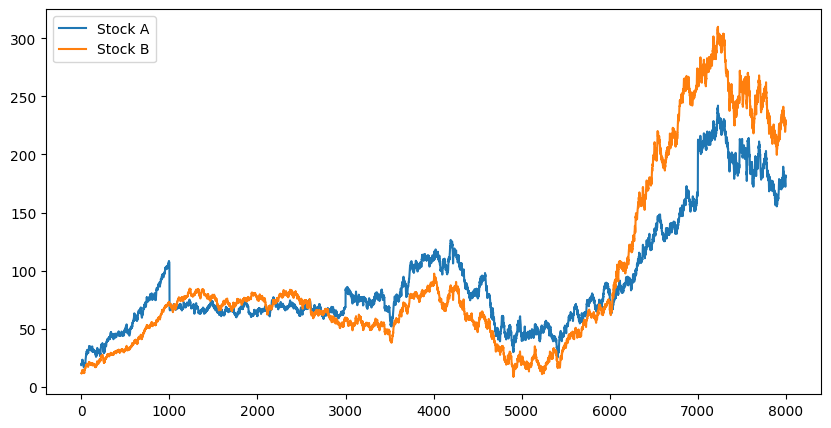

In [28]:
s1 = data_apple.values
s2 = data_microsoft.values

window_size = 400
points_per_window = 1000
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
for i in range(len(s1)//window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    for j in range(points_per_window):
        epst = params["c1"]+params["sigma1"]*np.random.normal()+params["phi1"]*epst
        et = params["c2"]+params["sigma2"]*np.random.normal()+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

for i in range(len(s1) // window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    print(f"Window {i}: c1={params["c1"]} c2={params["c2"]} phi1={params['phi1']:.3f}, phi2={params['phi2']:.3f}, "
          f"sigma1={params['sigma1']:.4f}, sigma2={params['sigma2']:.4f}, "
          f"beta={params['beta']:.3f}")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s1_gen, label = "Stock A")
ax.plot(s2_gen, label = "Stock B")
# ax.set_yscale('log')
ax.legend()
plt.show()

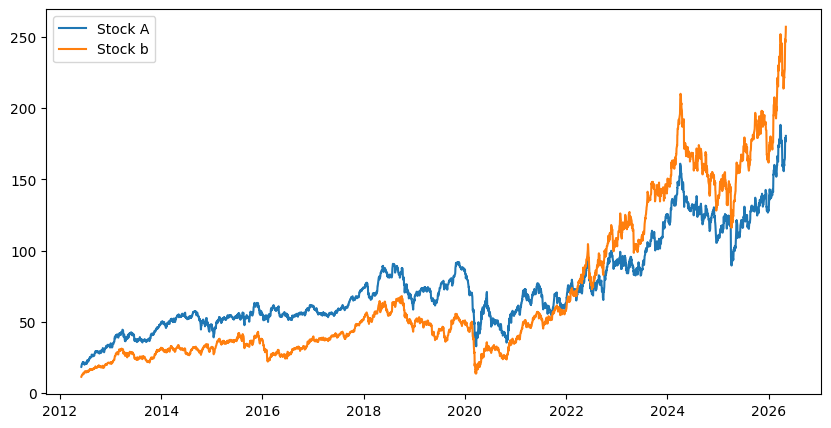

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data_apple, label="Stock A")
ax.plot(data_microsoft, label="Stock b")
# ax.set_yscale('log')
ax.legend()

In [30]:
s1 = np.log(data_apple.values)
s2 = np.log(data_microsoft.values)

window_size = 300
points_per_window = 100
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
betas = []
for i in range(len(s1)-window_size):
    params = estimate_all_params(s1[i:i+window_size], s2[i:i+window_size])
    betas.append(params["beta"])
    for j in range(points_per_window):
        epst = params["c1"]/points_per_window+params["sigma1"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi1"]*epst
        et = params["c2"]/points_per_window+params["sigma2"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

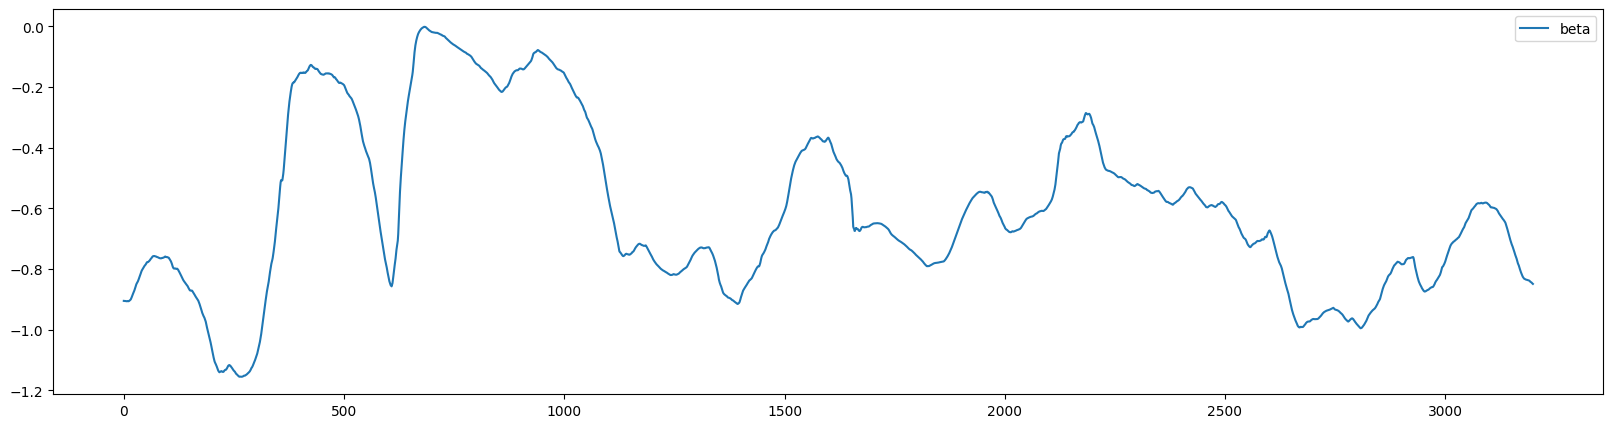

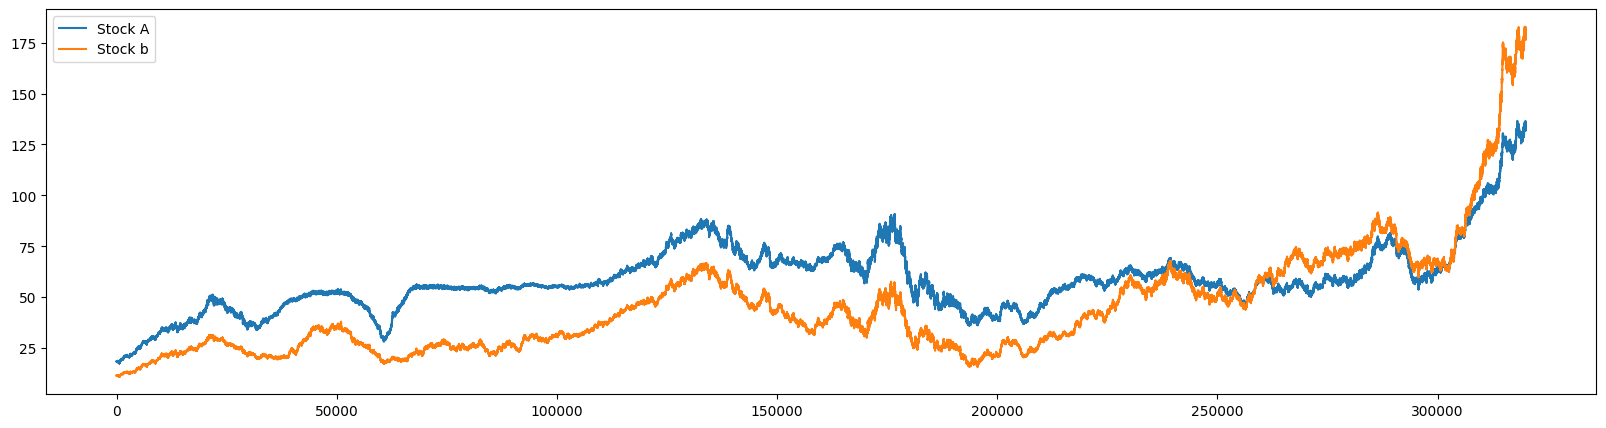

In [31]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(betas, label = "beta")
ax.legend()
plt.show()
s1_gen = np.array(s1_gen)
s2_gen = np.array(s2_gen)
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(np.exp(s1_gen[1:]), label="Stock A")
ax.plot(np.exp(s2_gen[1:]), label="Stock b")
# ax.set_yscale('log')
ax.legend()